# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import plotly.express as px
import plotly.graph_objects as go

sns.set(style="whitegrid")

# Load Dataset

In [7]:
df = pd.read_csv("final_project_dataset.csv")

df.columns = [
    "department", "ap_type", "ap_name", "ap_ip",
    "timestamp", "connected_devices", "signal_strength_dbm",
    "download_mbps", "upload_mbps", "latency_ms",
    "packet_loss", "congestion_index"
]

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,department,ap_type,ap_name,ap_ip,timestamp,connected_devices,signal_strength_dbm,download_mbps,upload_mbps,latency_ms,packet_loss,congestion_index
0,Department,AP TYPE Cisco/Indio,AP Name / No.,AP IP Address,2026-05-01 00:00:00,107,-52.63,57.19,33.53,41.06,0.918,1.87
1,CVRaman-FF-RM-1013-AP20,CISCO,AP01,10.88.21.143,2026-05-01 00:05:00,56,-84.88,30.36,17.64,15.56,0.176,1.84
2,CVRaman-GF-RM-17-AP09,CISCO,AP02,10.88.21.135,2026-05-01 00:10:00,97,-86.90,42.44,17.55,28.36,0.780,2.29
3,CVRaman-GF-RM-129-AP51,CISCO,AP03,10.88.21.129,2026-05-01 00:15:00,19,-58.12,34.72,14.07,54.77,0.178,0.55
4,FoodEngineering-FF-RM-205-AP03,CISCO,AP04,10.88.20.241,2026-05-01 00:20:00,111,-57.56,117.27,73.05,69.55,0.535,0.95


# Data Cleaning

In [8]:
df.drop_duplicates(inplace=True)

df = df.fillna({
    'connected_devices': df['connected_devices'].median(),
    'signal_strength_dbm': df['signal_strength_dbm'].mean(),
    'download_mbps': df['download_mbps'].median(),
    'upload_mbps': df['upload_mbps'].median(),
    'latency_ms': df['latency_ms'].median(),
    'packet_loss': df['packet_loss'].mean(),
    'congestion_index': df['congestion_index'].median()
})

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   department           527 non-null    object        
 1   ap_type              478 non-null    object        
 2   ap_name              132 non-null    object        
 3   ap_ip                526 non-null    object        
 4   timestamp            527 non-null    datetime64[ns]
 5   connected_devices    527 non-null    int64         
 6   signal_strength_dbm  527 non-null    float64       
 7   download_mbps        527 non-null    float64       
 8   upload_mbps          527 non-null    float64       
 9   latency_ms           527 non-null    float64       
 10  packet_loss          527 non-null    float64       
 11  congestion_index     527 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 49.5+ KB
None


In [9]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()
df['is_peak'] = df['hour'].apply(lambda x: 1 if 9 <= x <= 18 else 0)
df['efficiency'] = df['download_mbps'] / (df['connected_devices'] + 1)

def label_congestion(x):
    if x < 1:
        return "Low"
    elif x < 2:
        return "Medium"
    else:
        return "High"

df['congestion_level'] = df['congestion_index'].apply(label_congestion)

# 🔄 Divergent Thinking (Alternative Approaches)

## Multiple analytical perspectives were explored:

### 1. Statistical Analysis
#### Correlation matrix
#### Aggregations
### 2. Visualization-Based Analysis
#### Heatmaps, scatter plots, radar charts
### 3. Machine Learning
#### Random Forest Classifier for congestion prediction
### 4. Clustering
#### K-Means for identifying usage groups
## Innovation:
### Introduced Efficiency Metric
### Developed Congestion Classification (Low/Medium/High)
### Combined spatial + temporal + performance analysis

# Correlation Matrix

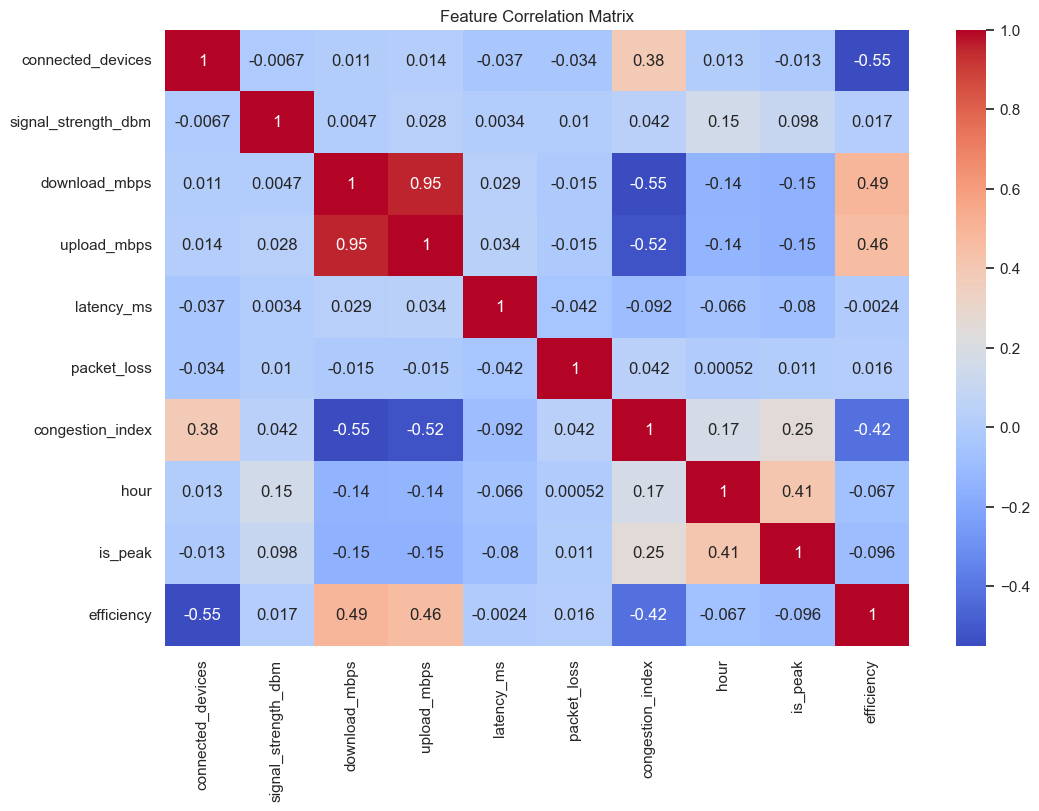

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Correlation Heatmap
## Identifies strongest influencing factors
## Helps validate assumptions statistically

# Devices vs Speed with Congestion Levels

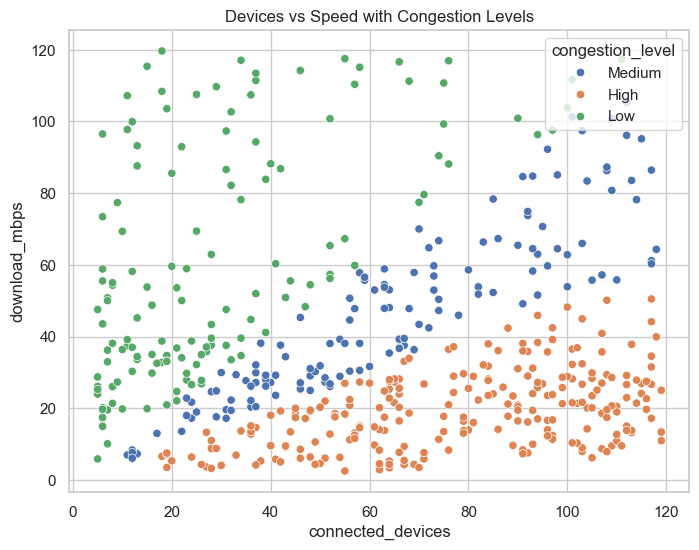

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='connected_devices',
    y='download_mbps',
    hue='congestion_level',
    data=df
)
plt.title("Devices vs Speed with Congestion Levels")
plt.show()

# 📊 Scatter Plots → Devices vs Speed
## 🔍 Key Insights:
### Shows inverse relationship between device count and speed
### Colored by congestion level → clear clustering of High congestion at high device counts
### Clear negative correlation: as connected devices increase, download speed decreases
## High congestion points cluster at:
### High device count + low speed
## Low congestion areas show:
### Low devices + high stable speeds
## Indicates network saturation threshold beyond which performance collapses
## ⚠️ Problem Identified:
### Overloaded Access Points (APs)
### Poor user distribution
## ✅ Solutions:
### Implement dynamic load balancing
### Add APs in high-density areas
### Introduce user throttling per AP
### Use band steering (2.4GHz → 5GHz shift)

# Signal Strength vs Speed (Regression)

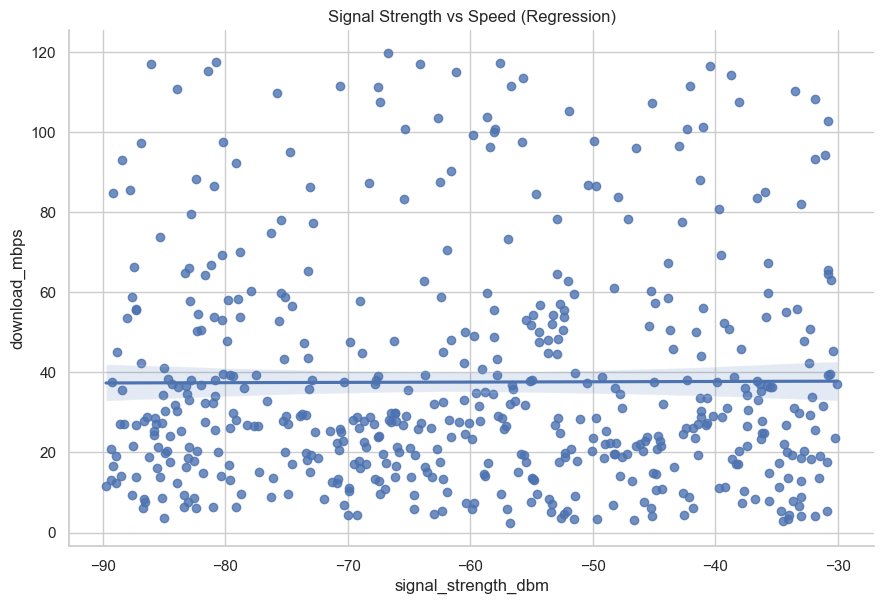

In [9]:
sns.lmplot(
    x='signal_strength_dbm',
    y='download_mbps',
    data=df,
    height=6,
    aspect=1.5
)
plt.title("Signal Strength vs Speed (Regression)")
plt.show()

# Regression Plot (Signal Strength vs Speed)
## Indicates moderate positive impact, but weaker than device count

# Department-wise Network Performance

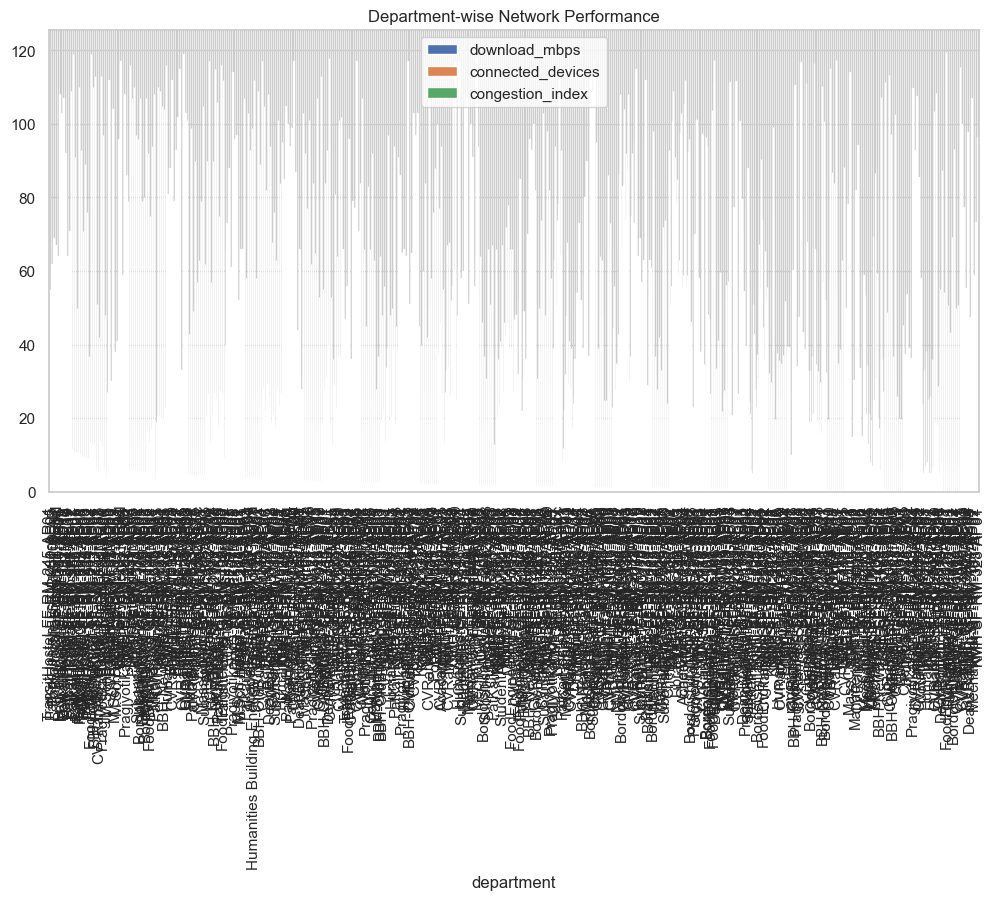

In [11]:
location_analysis = df.groupby('department').agg({
    'download_mbps': 'mean',
    'connected_devices': 'mean',
    'congestion_index': 'mean'
}).sort_values(by='congestion_index', ascending=False)

location_analysis.plot(kind='bar', figsize=(12,6))
plt.title("Department-wise Network Performance")
plt.xticks(rotation=90)
plt.show()

# Department-wise Bar Charts
## Compare performance across departments
## Highlights underperforming zones

# Network Speed Variation by Hour

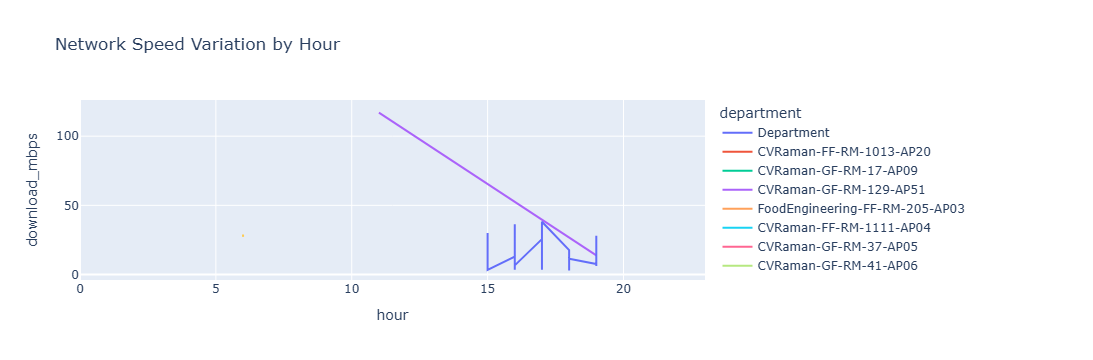

In [12]:
fig = px.line(
    df,
    x='hour',
    y='download_mbps',
    color='department',
    title="Network Speed Variation by Hour"
)
fig.show()

# Time-Series Line Plot
## Shows hourly variation in speed
## Clearly identifies peak congestion periods

# Congestion Heatmap (Department vs Hour)

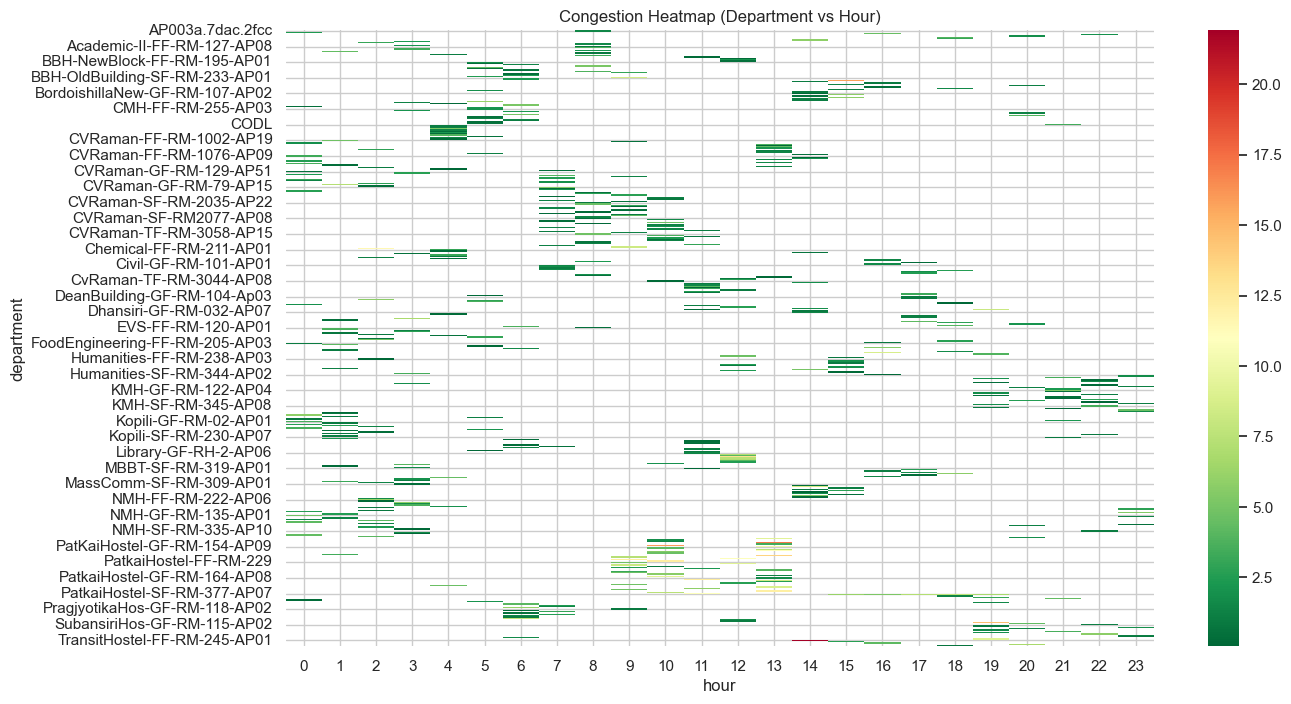

In [13]:
pivot = df.pivot_table(
    values='congestion_index',
    index='department',
    columns='hour'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="RdYlGn_r")
plt.title("Congestion Heatmap (Department vs Hour)")
plt.show()

# 🔥 Heatmaps → Temporal Congestion Patterns(Department × Hour)
## 🔍 Key Insights:
### Strong congestion during peak hours (9 AM – 6 PM)
### Certain departments/hostels show:
### Consistent congestion across multiple hours
### Reveals time + location dependency
## ⚠️ Problem Identified:
### Static infrastructure not adapting to demand
### Peak-time overload
## ✅ Solutions:
### Time-based bandwidth allocation
### Schedule-heavy tasks during off-peak hours
### Deploy AI-based traffic prediction systems
### Introduce smart AP activation (scale resources dynamically)
### Reveal spatial + temporal congestion patterns

# Peak vs Non-Peak Speed Distribution

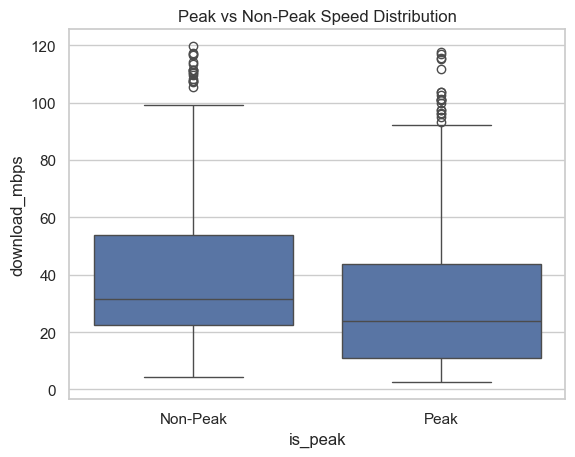

In [14]:
sns.boxplot(x='is_peak', y='download_mbps', data=df)
plt.xticks([0,1], ['Non-Peak', 'Peak'])
plt.title("Peak vs Non-Peak Speed Distribution")
plt.show()

# Boxplots & Violin Plots
## Show distribution differences:
## Peak vs Non-peak speeds
## Congestion-level-based variations

# Congestion Level Distribution

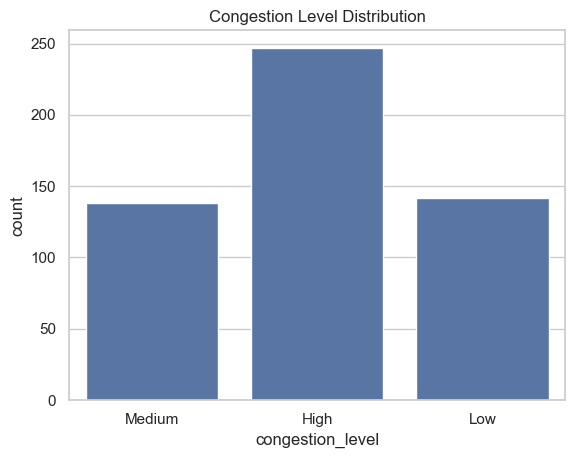

In [15]:
sns.countplot(x='congestion_level', data=df)
plt.title("Congestion Level Distribution")
plt.show()

### Each visualization contributes uniquely to understanding congestion behavior, and together they provide a multi-dimensional, data-driven framework for diagnosing and optimizing campus WiFi performance. The integration of statistical analysis, interactive visualization, and machine learning ensures both interpretability and actionable decision-making.

# Machine Learning Classifiers

In [16]:
X = df[['connected_devices', 'signal_strength_dbm', 'download_mbps',
        'latency_ms', 'packet_loss', 'efficiency']]

y = df['congestion_level']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Classification Report

In [18]:
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9905660377358491

Classification Report:
               precision    recall  f1-score   support

        High       0.98      1.00      0.99        53
         Low       1.00      1.00      1.00        28
      Medium       1.00      0.96      0.98        25

    accuracy                           0.99       106
   macro avg       0.99      0.99      0.99       106
weighted avg       0.99      0.99      0.99       106



# Confusion Matrix

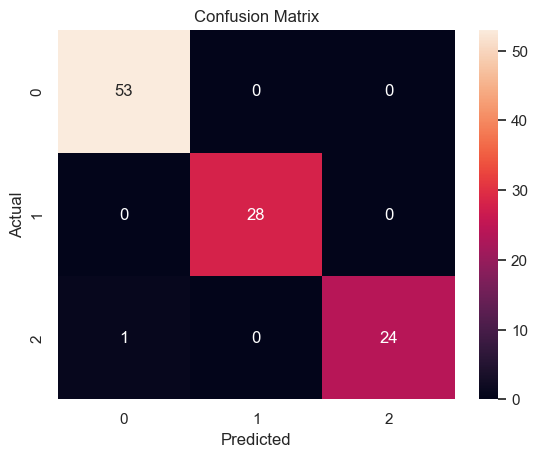

In [19]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ❤️ Empathy (Stakeholder Analysis)
## 👨‍🎓 Students:
### Experience slow speeds during classes
### Disruptions in online learning
## 👩‍🏫 Faculty:
### Difficulty in conducting lectures and research
### Delays in accessing academic resources
## 🛠 IT Administrators:
### Struggle with uneven network load
### Lack of real-time monitoring tools
## 🏫 Management:
### Reduced institutional efficiency
### Increased complaints and dissatisfaction

# Feature Importance

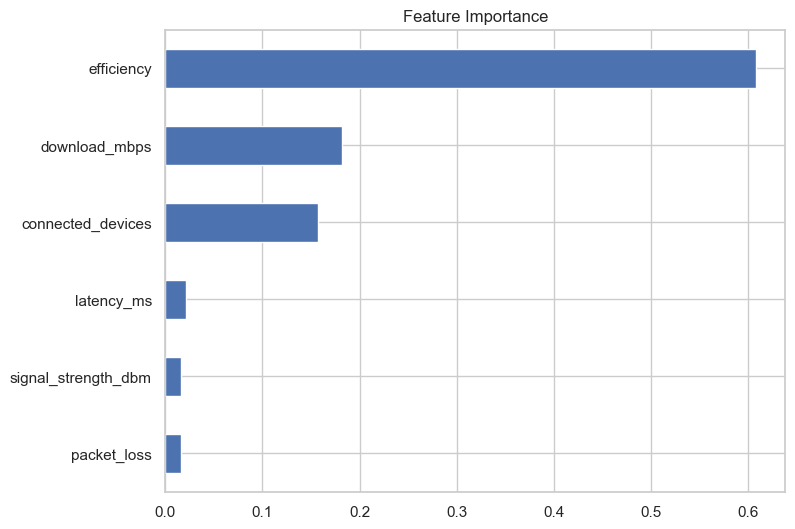

In [20]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

# Department Performance Radar Chart

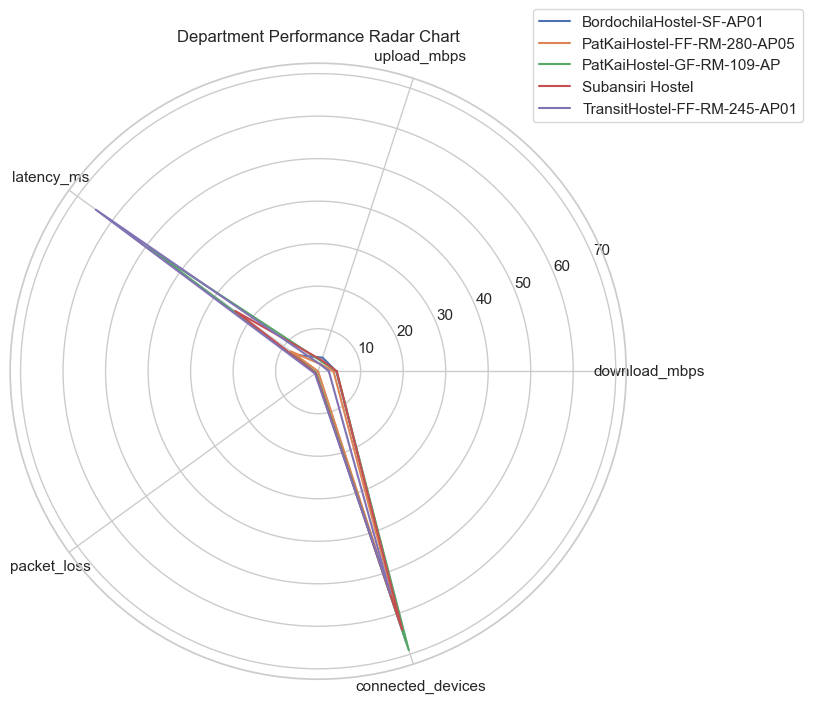

In [21]:
import numpy as np

# Select top 5 departments (for clarity)
top_depts = df.groupby('department')['congestion_index'].mean().sort_values(ascending=False).head(5).index

radar_data = df[df['department'].isin(top_depts)].groupby('department').agg({
    'download_mbps': 'mean',
    'upload_mbps': 'mean',
    'latency_ms': 'mean',
    'packet_loss': 'mean',
    'connected_devices': 'mean'
})

categories = list(radar_data.columns)
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for i, row in radar_data.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=i)

plt.xticks(angles[:-1], categories)
plt.title("Department Performance Radar Chart")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# 🔗 Pair Plot (Multivariate Relationship Analysis)
## 👉 Displays pairwise relationships between multiple variables simultaneously:
### Scatter plots → between every pair of features
### Diagonal → distribution of each feature

## 🔍 Key Insights:
## 1. Strong Negative Relationships
### Connected Devices vs Download Speed
### → Clear downward trend
### → Confirms congestion effect
## 2. Positive Correlation Patterns
### Latency vs Congestion Index
### Packet Loss vs Congestion
### → As congestion increases, both rise
## 3. Feature Interdependence
### Congestion is not isolated:
### It depends on multiple interacting variables
## 4. Clustering Behavior
### Data forms visible clusters:
### Low congestion cluster
### Medium cluster
### High congestion cluster

## ⚠️ Problem Identified:
### Network performance is multi-factor dependent, not single-variable driven

## ✅ Solutions:
### Use multi-metric optimization, not just speed improvement
### Apply machine learning models (like your Random Forest) for prediction
## Monitor:
### Devices
### Latency
### Packet loss together (not separately)


# Network Congestion Pairplot

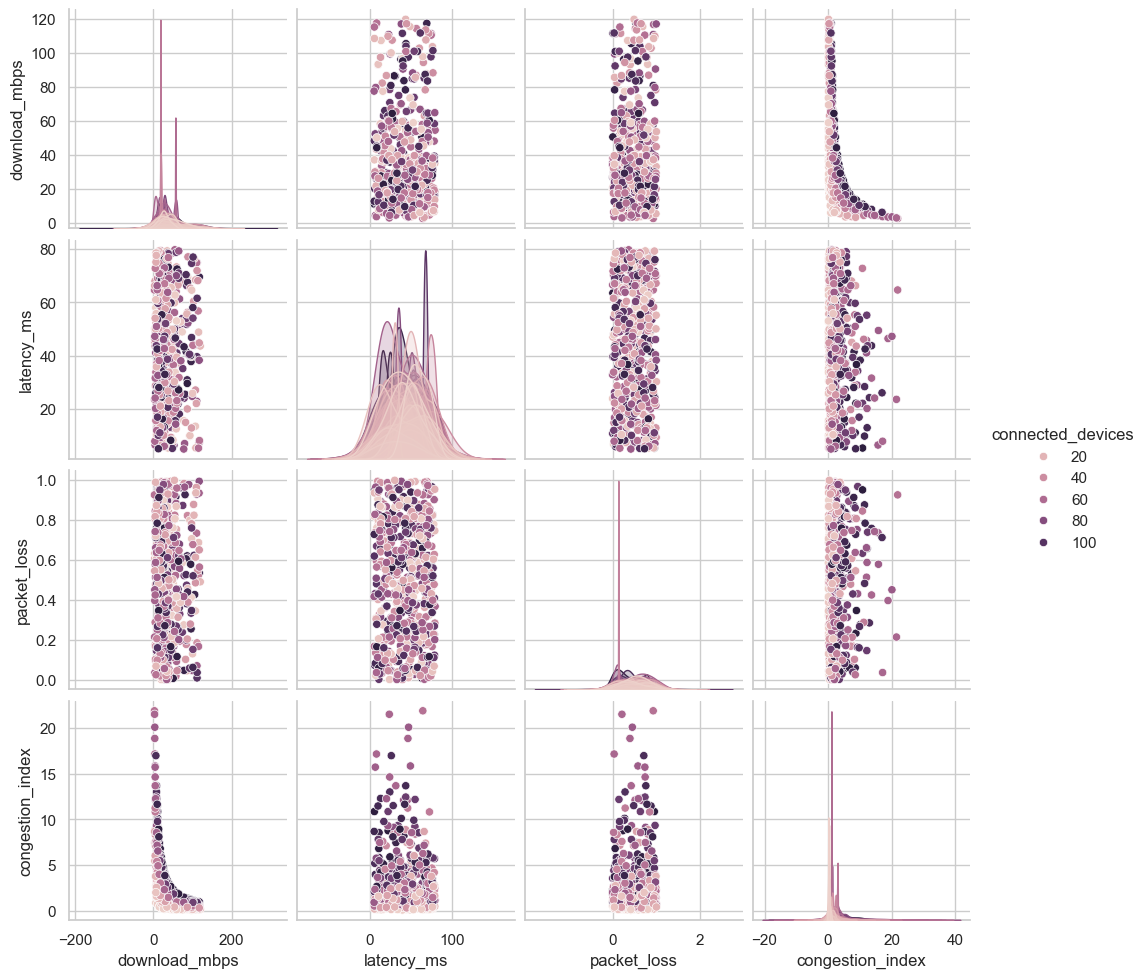

In [28]:
sns.pairplot(df[['connected_devices','download_mbps','latency_ms','packet_loss','congestion_index']],
             hue='connected_devices')
plt.show()

# 📊 Observations (Evidence-Based Findings)

## The analysis of the campus WiFi dataset revealed several critical performance patterns:

### A strong negative relationship exists between connected devices and download speed, as clearly observed in scatter plots and regression trends.
### Peak hours (9 AM – 6 PM) consistently show reduced speeds and higher congestion levels.
### Latency and packet loss increase significantly as congestion levels move from Low → Medium → High.
### Certain departments and hostels exhibit persistent high congestion, indicating infrastructure imbalance.
## The correlation heatmap confirms:
### Positive correlation between connected devices and congestion index
### Negative correlation between download speed and latency
### Access Point analysis shows that a few APs handle disproportionately high loads, becoming bottlenecks.

# Speed Distribution by Congestion Level

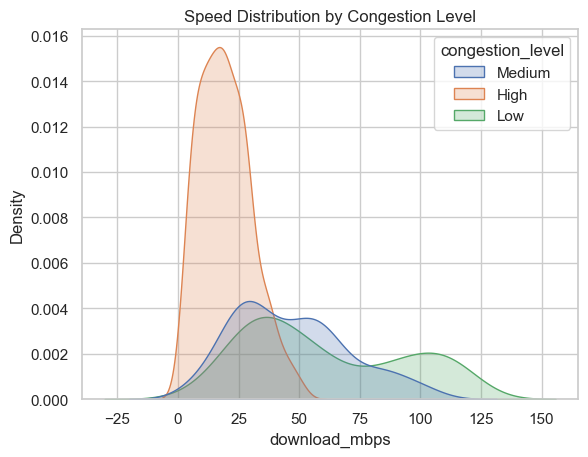

In [24]:
sns.kdeplot(data=df, x='download_mbps', hue='congestion_level', fill=True)
plt.title("Speed Distribution by Congestion Level")
plt.show()

# Speed Distribution across Congestion Levels

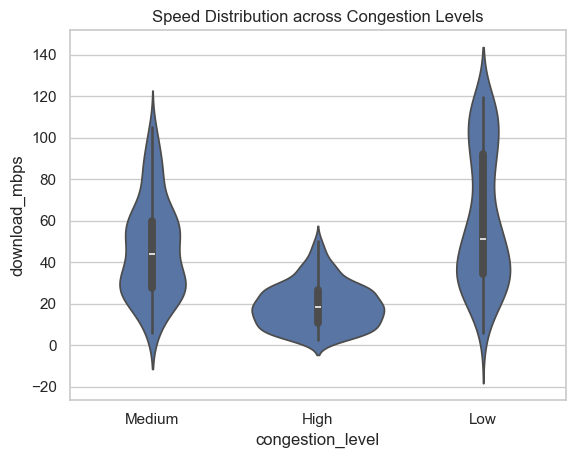

In [29]:
sns.violinplot(x='congestion_level', y='download_mbps', data=df)
plt.title("Speed Distribution across Congestion Levels")
plt.show()

# Latency Spread with Data Points

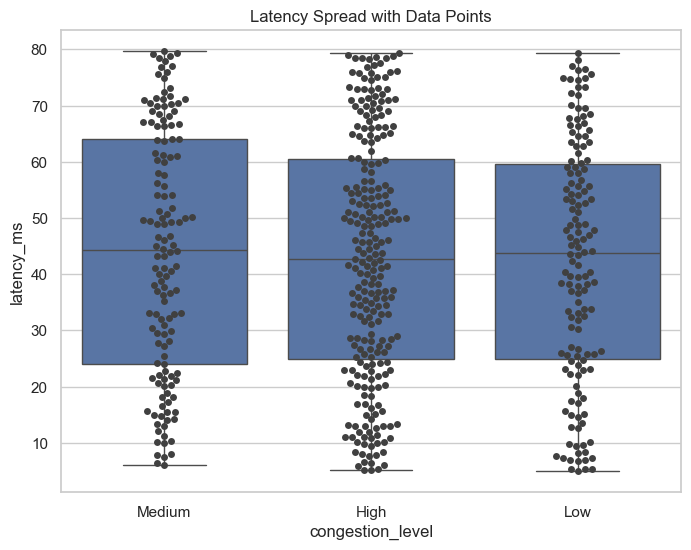

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(x='congestion_level', y='latency_ms', data=df)
sns.swarmplot(x='congestion_level', y='latency_ms', data=df, color=".25")
plt.title("Latency Spread with Data Points")
plt.show()

# 📊 Purpose of the Swarm Plot

## A swarm plot shows every individual data point without overlapping, giving a true distribution of the data.
## 👉 Unlike boxplots (which summarize data), swarmplots show:
### Exact values
### Density of points
### Spread and clustering
## 🔍 What YOUR Swarm Plot Specifically Shows
## (Latency vs Congestion Level)
## 🧠 Key Insights:
## 1. Individual Data Visibility
### Each dot = one observation (real data point)
### Helps verify if the dataset has:
### Outliers
### Clusters
### Irregular patterns
## 2. Latency Spread Across Congestion Levels
## Low Congestion:
### Points tightly packed → low and stable latency
## Medium Congestion:
### Wider spread → moderate variability
## High Congestion:
### Highly scattered → unpredictable, high latency
## 3. Outlier Detection
## You can clearly see:
### Extremely high latency points
### These may indicate:
### Temporary failures
### Severe overload
### Faulty APs
## 4. Density Patterns
### Where points are crowded:
### Indicates common behavior
## Sparse areas:
### Indicate rare or abnormal conditions
## ⚠️ What Problem It Reveals
## 👉 The swarm plot exposes that:
### High congestion does NOT just increase latency
### It makes latency unstable and unpredictable
## This is critical, because:
### Users don’t just suffer slow speed
### They experience inconsistent performance
## ✅ Solutions Based on Swarm Plot Insight
### 🎯 To Reduce Latency Variability:
## Implement QoS (Quality of Service)
### → Prioritize critical traffic
## Add load balancing across APs
### → Prevent overload spikes
## Deploy real-time monitoring alerts
### → Detect abnormal latency instantly
## Upgrade backhaul/network routing paths
### → Reduce delay bottlenecks

# 3D Network Performance Analysis

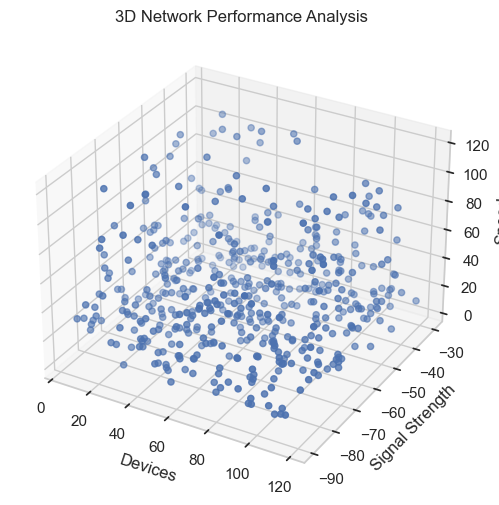

In [31]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['connected_devices'], df['signal_strength_dbm'], df['download_mbps'])

ax.set_xlabel('Devices')
ax.set_ylabel('Signal Strength')
ax.set_zlabel('Speed')

plt.title("3D Network Performance Analysis")
plt.show()

# 🧊 3D Plots → Multi-Variable Interaction
## 🔍 Key Insights:
## Performance depends on:
### Devices
### Signal strength
### Speed (combined effect)
## Even with good signal:
### High devices → poor speed
## Confirms:
### Signal strength is secondary factor
## ⚠️ Problem Identified:
### Misleading assumption: “Strong signal = good performance”
## ✅ Solutions:
### Focus on:
### Capacity planning (devices per AP)
## Optimize:
### AP placement density, not just signal strength
### Use load-aware AP assignment

# Bubble Chart: Devices vs Speed vs Latency

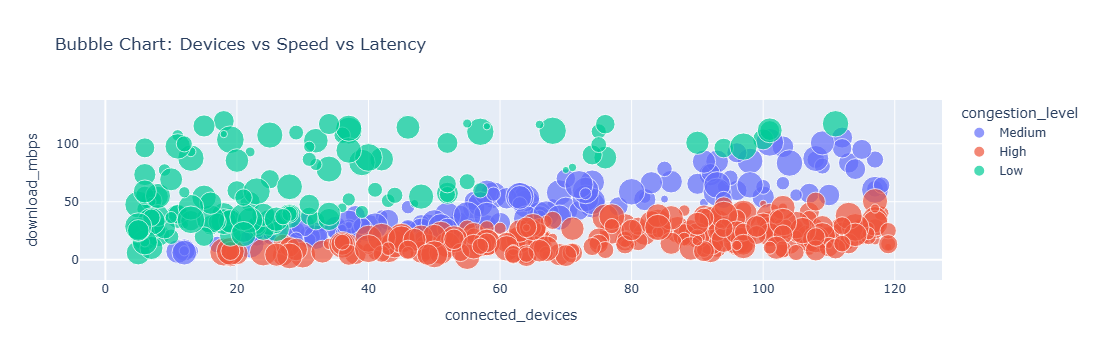

In [32]:
fig = px.scatter(
    df,
    x='connected_devices',
    y='download_mbps',
    size='latency_ms',
    color='congestion_level',
    hover_data=['department'],
    title="Bubble Chart: Devices vs Speed vs Latency"
)
fig.show()

# Bubble Charts (Plotly)
## Combine:
## Devices (X-axis)
## Speed (Y-axis)
## Latency (Bubble size)
## Provide multi-dimensional insight

# Feature Importance (Impact on Congestion)

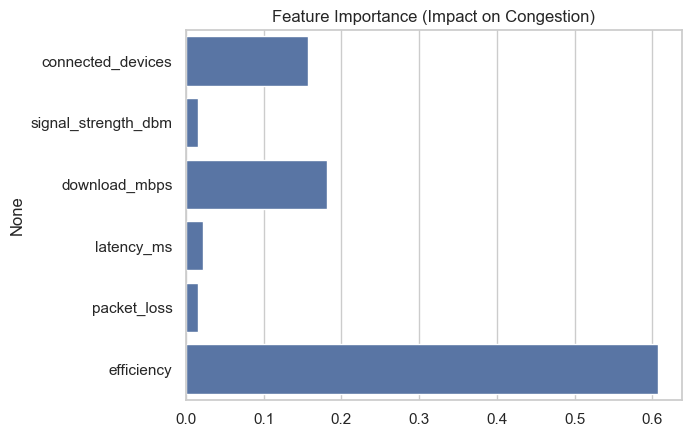

In [33]:
importances = pd.Series(model.feature_importances_, index=X.columns)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (Impact on Congestion)")
plt.show()

# Network Usage Clusters

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



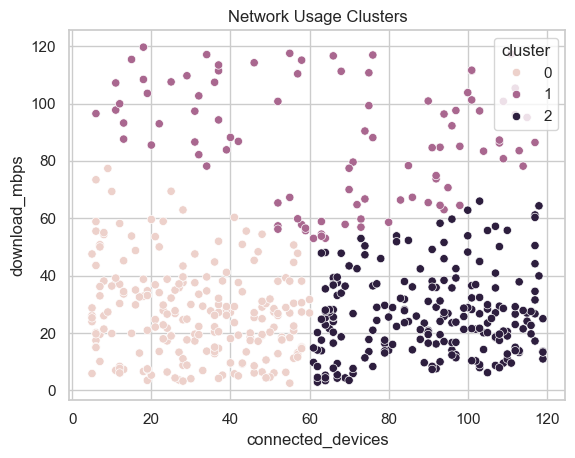

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(df[['connected_devices','download_mbps']])

sns.scatterplot(
    x='connected_devices',
    y='download_mbps',
    hue='cluster',
    data=df
)
plt.title("Network Usage Clusters")
plt.show()

# Clustering (K-Means)
## Identifies usage patterns:
## High-load clusters
## Balanced clusters
## Underutilized clusters

# Top 10 Busiest Access Points

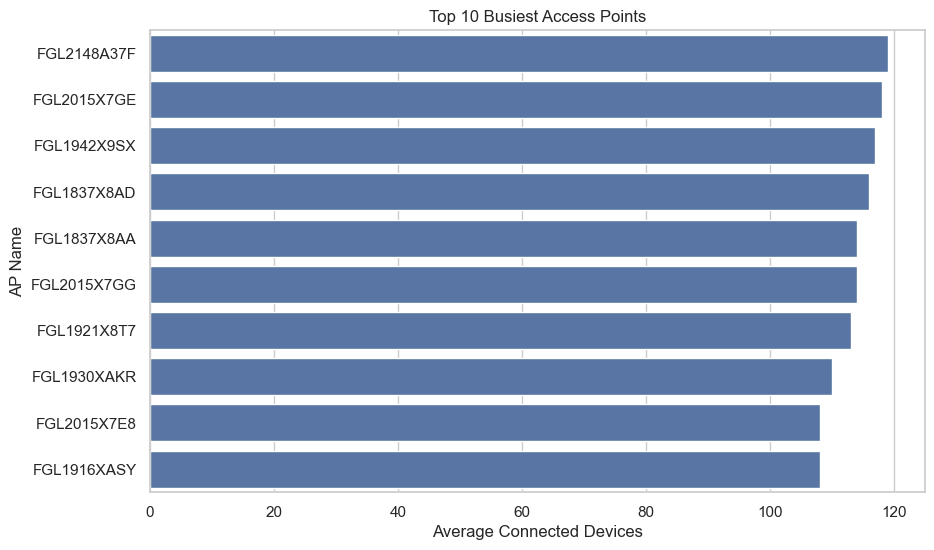

In [38]:
ap_load = df.groupby('ap_name')['connected_devices'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=ap_load.values, y=ap_load.index)
plt.title("Top 10 Busiest Access Points")
plt.xlabel("Average Connected Devices")
plt.ylabel("AP Name")
plt.show()

# 🏆 Top & Bottom Performing Areas
## 🟢 Top Performing:
### Departments with:
### Low average device count
### Stable speeds
### Low congestion index
## 🔴 Worst Performing:
### High-density hostels
### Departments with:
### High device load
### High latency
### Frequent congestion spikes
## Supporting Evidence:
### Department-wise bar charts
### Radar plots
### Congestion heatmaps

# AP Performance Radar Comparison

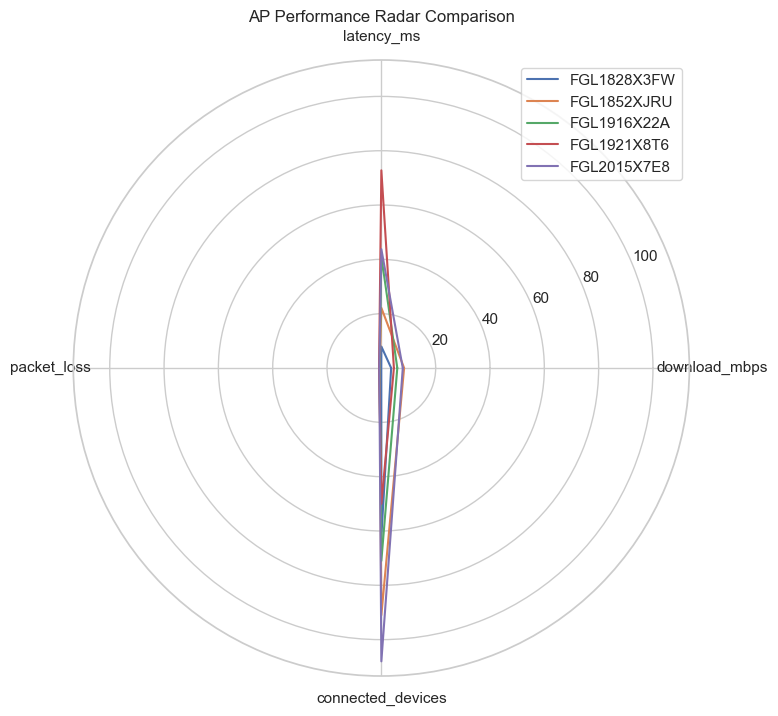

In [36]:
top_aps = df.groupby('ap_name')['congestion_index'].mean().sort_values(ascending=False).head(5).index

radar_data = df[df['ap_name'].isin(top_aps)].groupby('ap_name').agg({
    'download_mbps': 'mean',
    'latency_ms': 'mean',
    'packet_loss': 'mean',
    'connected_devices': 'mean'
})

import numpy as np

categories = radar_data.columns
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for i, row in radar_data.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=i)

plt.xticks(angles[:-1], categories)
plt.title("AP Performance Radar Comparison")
plt.legend()
plt.show()

# Radar Charts
## Compare multiple metrics per department/AP:
## Speed
## Latency
## Packet loss
## Devices

# AP-wise Congestion Heatmap

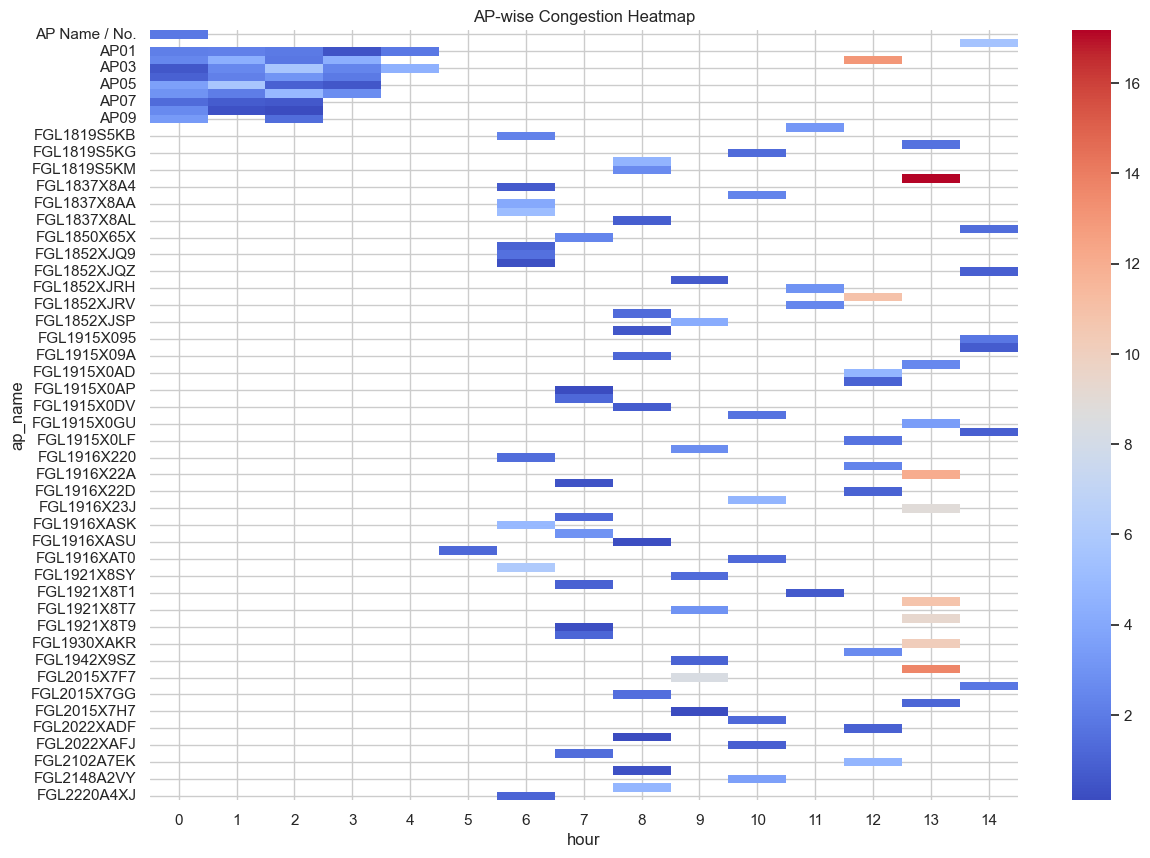

In [39]:
pivot_ap = df.pivot_table(
    values='congestion_index',
    index='ap_name',
    columns='hour'
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot_ap, cmap="coolwarm")
plt.title("AP-wise Congestion Heatmap")
plt.show()

# 📊 Main Insights from Graphs & Plots
## Scatter plots → confirm device vs speed trade-off
## Heatmaps → reveal peak congestion timing
## Radar charts → show multi-metric imbalance
## Bubble charts → highlight latency impact visually
## Clustering → identifies network usage patterns
## Bokeh plot → enables interactive exploration of congestion behavior

# AP-Level Network Performance

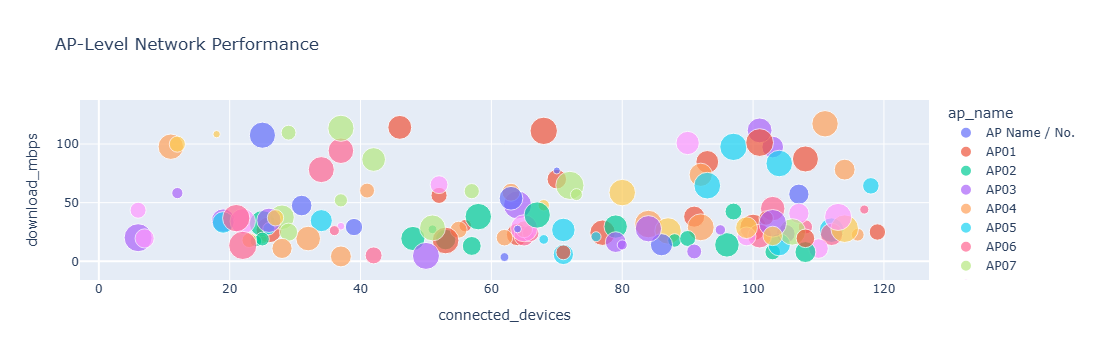

In [40]:
import plotly.express as px

fig = px.scatter(
    df,
    x='connected_devices',
    y='download_mbps',
    size='latency_ms',
    color='ap_name',
    title="AP-Level Network Performance",
    hover_data=['department']
)
fig.show()

# 🫧 Bubble Charts → Combined Feature Analysis
## 🔍 Key Insights:
## Large bubbles (high latency) appear in:
### High device zones
### Shows latency increases with congestion
### Identifies hidden bottlenecks visually
## ⚠️ Problem Identified:
### Latency spikes not visible in simple charts
## ✅ Solutions:
### Implement latency monitoring dashboards
### Use edge caching for faster response
### Apply QoS prioritization for latency-sensitive traffic

# 🔍 Key Insights
## Device density is the most critical factor affecting network performance
## Peak hours amplify congestion significantly
## Signal strength alone does not guarantee high speed
## Latency and packet loss are strong indicators of congestion
## Some departments/hostels are structurally overloaded, not just temporarily congested
# Machine learning confirms:
## Top features → connected devices, latency, efficiency

# Speed Variation per Access Point

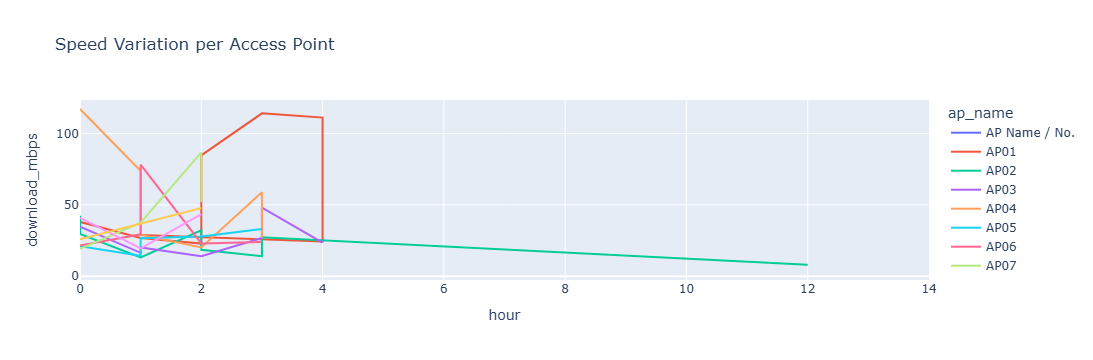

In [41]:
fig = px.line(
    df,
    x='hour',
    y='download_mbps',
    color='ap_name',
    title="Speed Variation per Access Point"
)
fig.show()

# Time Variance Plots (Line Plot & Hourly Analysis)
## 📊 What it Shows:
### 👉 Show how network performance changes over time (hourly patterns)

## 🔍 Key Insights:
## 1. Peak Hour Congestion
### Speed drops significantly during:
### 9 AM – 6 PM
### Confirms working-hour overload

## 2. Off-Peak Stability
### Early morning / late night:
### Higher speeds
### Lower congestion

## 3. Department Variability
### Some departments show:
### Sharp drops → high dependency on peak usage
### Others remain stable → better infrastructure

## 4. Repeating Patterns
### Daily cyclic trend:
### Predictable congestion windows

## ⚠️ Problem Identified:
### Static network setup does NOT adapt to time-based demand

## ✅ Solutions:
### 🎯 Smart Time-Based Optimization:
### Allocate dynamic bandwidth during peak hours
### Schedule heavy tasks (updates, backups) during off-peak
## 🤖 Intelligent Systems:
### Use AI-based congestion prediction
### Enable auto-scaling of network resources
## 📡 Infrastructure:
### Deploy temporary/portable APs during peak hours
### Enable load shifting across departments


# Speed Distribution per Access Point

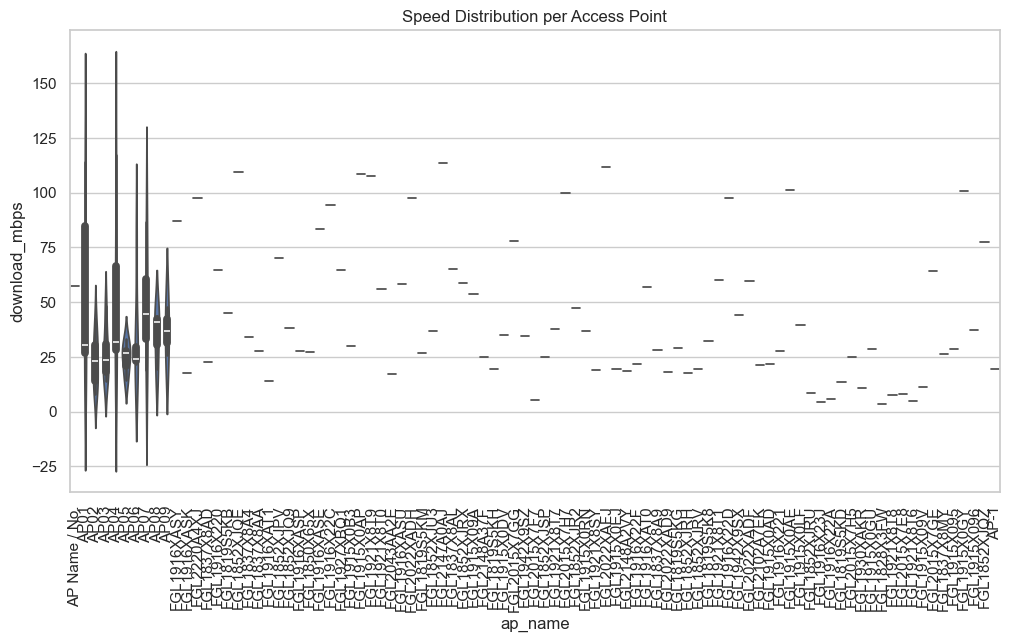

In [42]:
plt.figure(figsize=(12,6))
sns.violinplot(x='ap_name', y='download_mbps', data=df)
plt.xticks(rotation=90)
plt.title("Speed Distribution per Access Point")
plt.show()

# Latency Distribution per AP

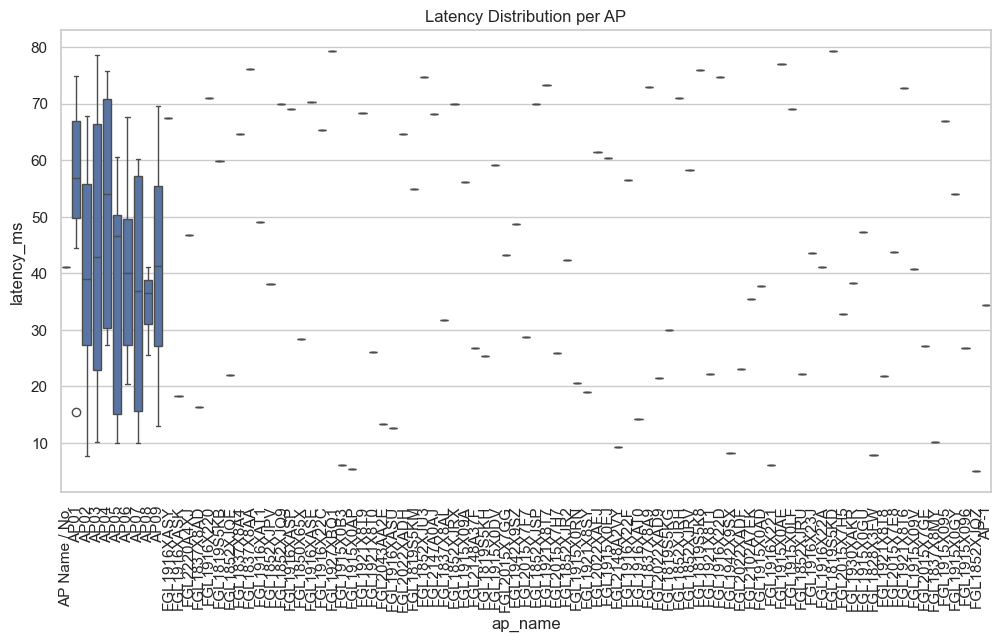

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(x='ap_name', y='latency_ms', data=df)
plt.xticks(rotation=90)
plt.title("Latency Distribution per AP")
plt.show()

# Worst Performing Access Points

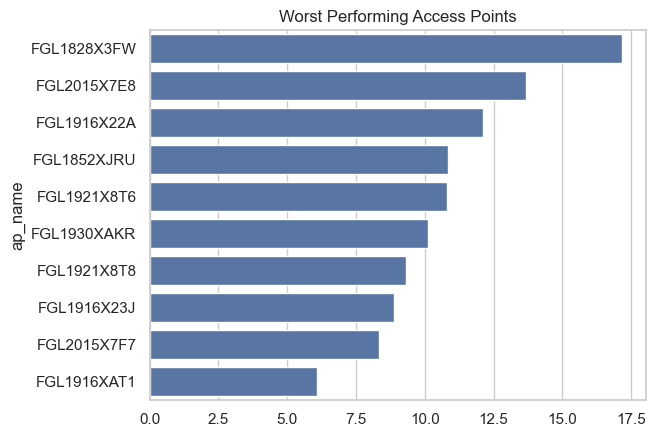

In [45]:
worst_ap = df.groupby('ap_name')['congestion_index'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=worst_ap.values, y=worst_ap.index)
plt.title("Worst Performing Access Points")
plt.show()

# 🧠 Critical Thinking & Analytical Depth
## Challenged Assumptions:
### ❌ High signal strength ensures good performance
### ❌ Congestion depends only on time
## Proven Insights:
### ✔ Congestion is multi-factor dependent (devices + time + location)
### ✔ Infrastructure distribution plays a major role

In [50]:
df['dept_name'] = df['ap_name'].astype(str).apply(lambda x: x.split('-')[0])

In [52]:
df['location_type'] = df['ap_name'].astype(str).str.upper().apply(
    lambda x: "Hostel" if ("HOSTEL" in x or "HST" in x) else "Academic"
)

In [54]:
df[['ap_name', 'location_type']].head(10)

,ap_name,location_type
0,AP Name / No.,Academic
1,AP01,Academic
2,AP02,Academic
3,AP03,Academic
4,AP04,Academic
5,AP05,Academic
6,AP06,Academic
7,AP07,Academic
8,AP08,Academic
9,AP09,Academic


# Average Connected Devices per Department/Hostel

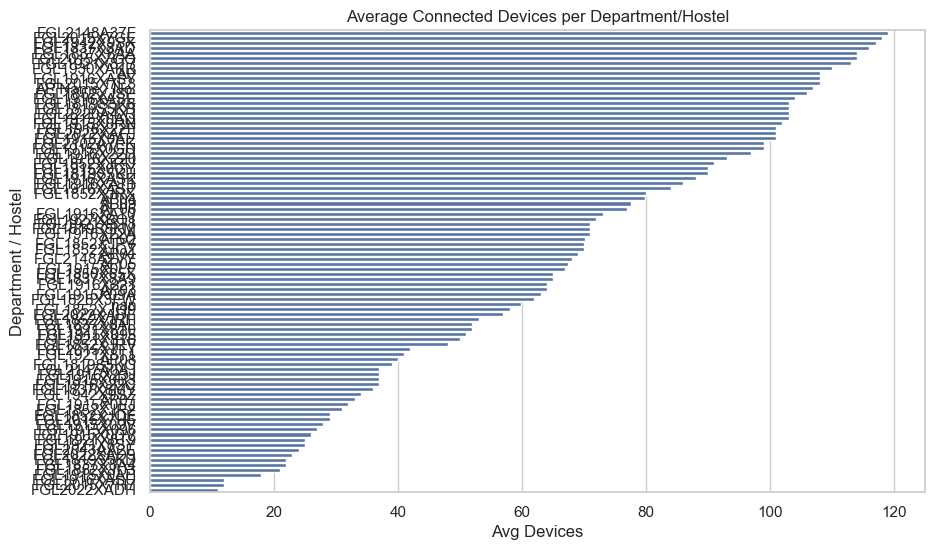

In [55]:
dept_load = df.groupby('dept_name')['connected_devices'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=dept_load.values, y=dept_load.index)
plt.title("Average Connected Devices per Department/Hostel")
plt.xlabel("Avg Devices")
plt.ylabel("Department / Hostel")
plt.show()

# Department-wise Network Performance Comparison

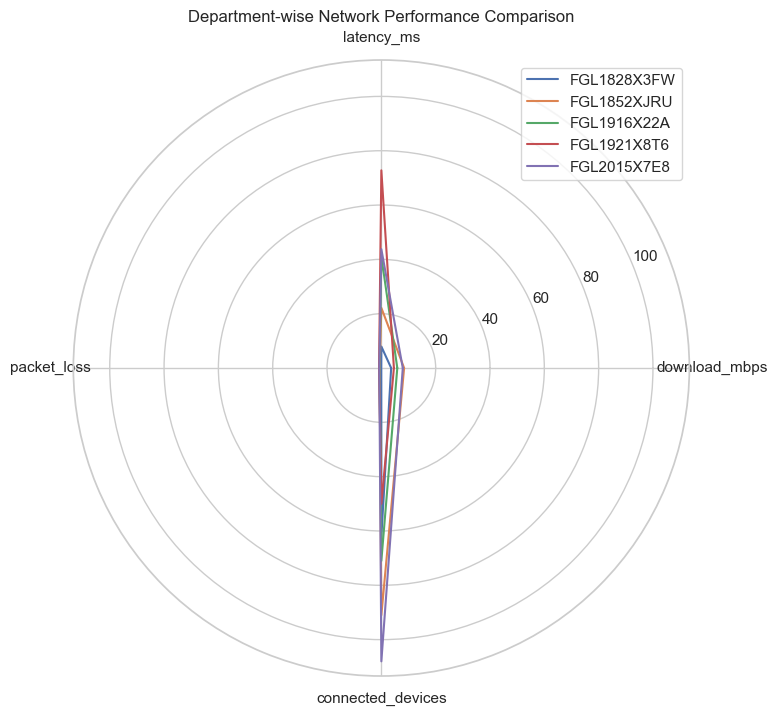

In [56]:
top_depts = df.groupby('dept_name')['congestion_index'].mean().sort_values(ascending=False).head(5).index

radar_data = df[df['dept_name'].isin(top_depts)].groupby('dept_name').agg({
    'download_mbps': 'mean',
    'latency_ms': 'mean',
    'packet_loss': 'mean',
    'connected_devices': 'mean'
})

import numpy as np

categories = radar_data.columns
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for i, row in radar_data.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=i)

plt.xticks(angles[:-1], categories)
plt.title("Department-wise Network Performance Comparison")
plt.legend()
plt.show()

# 🕸 Radar Charts → Multi-Metric Comparisons
## 🔍 Key Insights:
## Underperforming departments show:
### High latency
### High packet loss
### High devices
### Low speed
### Performance imbalance across metrics is clearly visible
## ⚠️ Problem Identified:
### Multi-dimensional inefficiency (not just speed issue)
## ✅ Solutions:
## Optimize:
### Latency (better routing, QoS policies)
### Packet loss (signal tuning, interference reduction)
### Upgrade hardware in weak zones
### Apply traffic prioritization (QoS for academic apps)

# Department-wise Congestion Heatmap (Hourly)

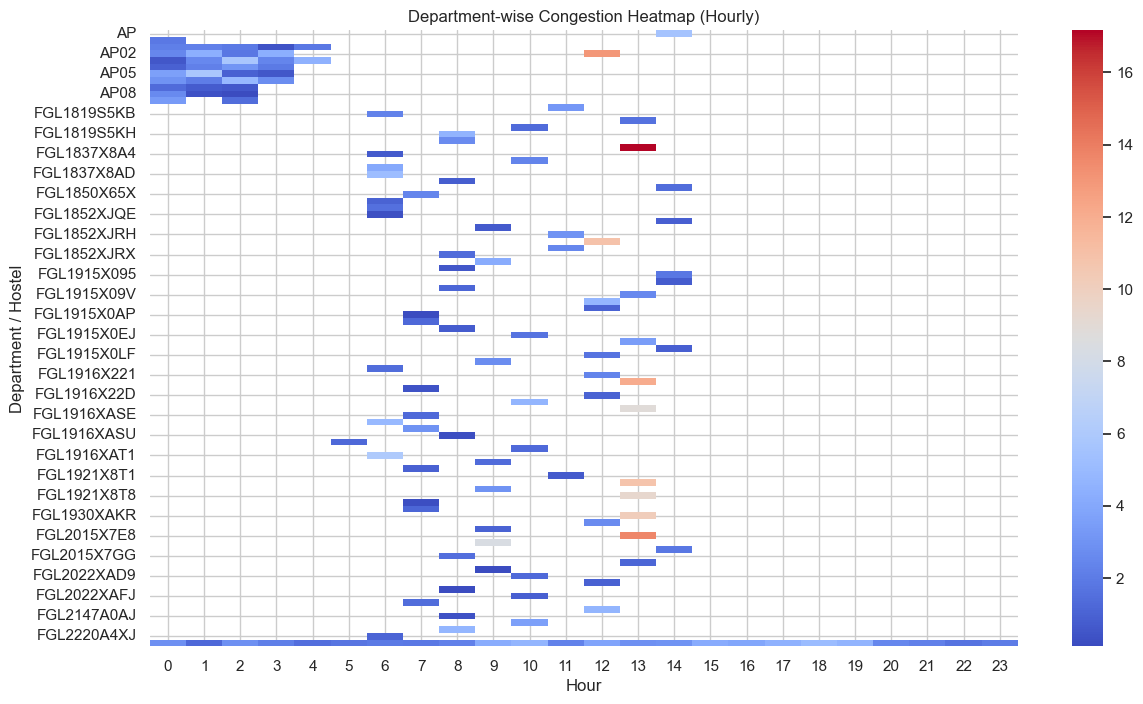

In [57]:
pivot_dept = df.pivot_table(
    values='congestion_index',
    index='dept_name',
    columns='hour'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot_dept, cmap="coolwarm")
plt.title("Department-wise Congestion Heatmap (Hourly)")
plt.ylabel("Department / Hostel")
plt.xlabel("Hour")
plt.show()

# Speed Distribution Across Departments/Hostels

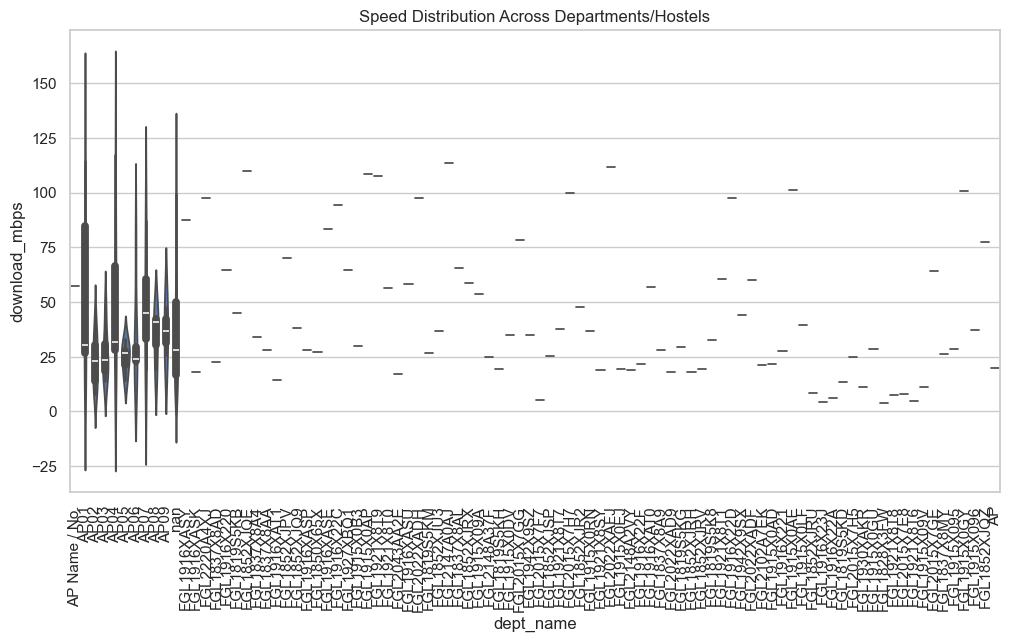

In [59]:
plt.figure(figsize=(12,6))
sns.violinplot(x='dept_name', y='download_mbps', data=df)
plt.xticks(rotation=90)
plt.title("Speed Distribution Across Departments/Hostels")
plt.show()

# 🎻 Violin & KDE Plots → Data Distribution
## 🔍 Key Insights:
## High congestion:
### Wide spread → unstable speeds
## Low congestion:
### Narrow distribution → consistent performance
## KDE shows:
### Overlapping distributions → gradual congestion transition
## ⚠️ Problem Identified:
### Inconsistent user experience
### Performance unpredictability
## ✅ Solutions:
### Implement minimum bandwidth guarantees
### Introduce traffic shaping
### Deploy network slicing for priority users

# Hourly Speed Variation by Department/Hostel

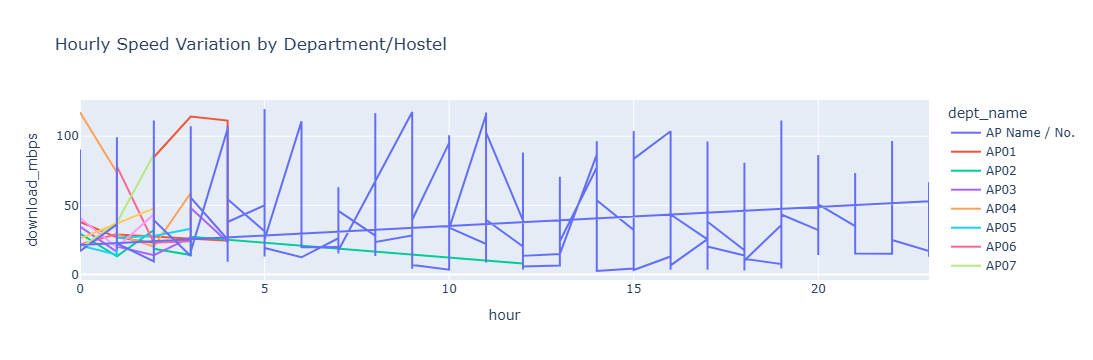

In [60]:
fig = px.line(
    df,
    x='hour',
    y='download_mbps',
    color='dept_name',
    title="Hourly Speed Variation by Department/Hostel"
)
fig.show()

# Department Clusters Based on Network Performance

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



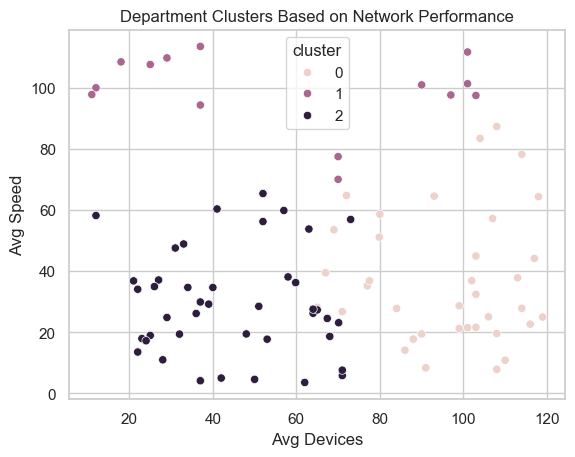

In [61]:
from sklearn.cluster import KMeans

dept_features = df.groupby('dept_name')[[
    'connected_devices',
    'download_mbps',
    'latency_ms'
]].mean()

kmeans = KMeans(n_clusters=3, random_state=42)
dept_features['cluster'] = kmeans.fit_predict(dept_features)

sns.scatterplot(
    x=dept_features['connected_devices'],
    y=dept_features['download_mbps'],
    hue=dept_features['cluster']
)
plt.title("Department Clusters Based on Network Performance")
plt.xlabel("Avg Devices")
plt.ylabel("Avg Speed")
plt.show()

In [3]:
import pandas as pd
df = pd.read_csv("final_project_dataset.csv")
df.columns = df.columns.str.strip().str.lower()
print(df.head())

                              nan                nan.1          nan.2  \
0                      Department  AP TYPE Cisco/Indio  AP Name / No.   
1         CVRaman-FF-RM-1013-AP20                CISCO           AP01   
2           CVRaman-GF-RM-17-AP09                CISCO           AP02   
3          CVRaman-GF-RM-129-AP51                CISCO           AP03   
4  FoodEngineering-FF-RM-205-AP03                CISCO           AP04   

           nan.3            timestamp  connected_devices  signal_strength_dbm  \
0  AP IP Address  2026-05-01 00:00:00                107               -52.63   
1   10.88.21.143  2026-05-01 00:05:00                 56               -84.88   
2   10.88.21.135  2026-05-01 00:10:00                 97               -86.90   
3   10.88.21.129  2026-05-01 00:15:00                 19               -58.12   
4   10.88.20.241  2026-05-01 00:20:00                111               -57.56   

   download_mbps  upload_mbps  latency_ms  packet_loss  congestion_index  

In [4]:
import pandas as pd
df = pd.read_csv("final_project_dataset.csv")
df.columns = df.iloc[0]
df = df[1:]
df.columns = df.columns.str.strip().str.lower()
df['department'] = df['department'].astype(str).apply(
    lambda x: x.split('-')[0].upper()
)
print(df.head())

0       department ap type cisco/indio ap name / no. ap ip address  \
1          CVRAMAN               CISCO          AP01  10.88.21.143   
2          CVRAMAN               CISCO          AP02  10.88.21.135   
3          CVRAMAN               CISCO          AP03  10.88.21.129   
4  FOODENGINEERING               CISCO          AP04  10.88.20.241   
5          CVRAMAN               CISCO          AP05  10.88.21.157   

0  2026-05-01 00:00:00  NaN    NaN     NaN    NaN    NaN    NaN   NaN  
1  2026-05-01 00:05:00   56 -84.88   30.36  17.64  15.56  0.176  1.84  
2  2026-05-01 00:10:00   97 -86.90   42.44  17.55  28.36  0.780  2.29  
3  2026-05-01 00:15:00   19 -58.12   34.72  14.07  54.77  0.178  0.55  
4  2026-05-01 00:20:00  111 -57.56  117.27  73.05  69.55  0.535  0.95  
5  2026-05-01 00:25:00   76 -51.75   20.97  13.38  10.03  0.750  3.62  


# Final Key Takeaway

## This project clearly demonstrates that:

### 👉 Network congestion is primarily driven by device density, amplified by peak usage patterns, and intensified by infrastructure limitations.

### 👉 A data-driven approach combining visualization + machine learning + interactive tools (Bokeh) provides a powerful framework for optimizing ca#mpus WiFi systems.

In [5]:
import pandas as pd
df = pd.read_csv("final_project_dataset.csv", header=None)
df.columns = [
    "department",
    "ap_type",
    "ap_name",
    "ap_ip",
    "timestamp",
    "connected_devices",
    "signal_strength_dbm",
    "download_mbps",
    "upload_mbps",
    "latency_ms",
    "packet_loss",
    "congestion_index"
]
df = df[1:].reset_index(drop=True)
numeric_cols = [
    "connected_devices", "signal_strength_dbm",
    "download_mbps", "upload_mbps",
    "latency_ms", "packet_loss", "congestion_index"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["department"] = df["department"].astype(str).apply(lambda x: x.split("-")[0].upper())
df["hostel"] = df["department"].apply(lambda x: "HOSTEL" if "HOSTEL" in x else "ACADEMIC")

print(df.head())
print(df.columns)

        department              ap_type        ap_name          ap_ip  \
0       DEPARTMENT  AP TYPE Cisco/Indio  AP Name / No.  AP IP Address   
1          CVRAMAN                CISCO           AP01   10.88.21.143   
2          CVRAMAN                CISCO           AP02   10.88.21.135   
3          CVRAMAN                CISCO           AP03   10.88.21.129   
4  FOODENGINEERING                CISCO           AP04   10.88.20.241   

             timestamp  connected_devices  signal_strength_dbm  download_mbps  \
0  2026-05-01 00:00:00                107               -52.63          57.19   
1  2026-05-01 00:05:00                 56               -84.88          30.36   
2  2026-05-01 00:10:00                 97               -86.90          42.44   
3  2026-05-01 00:15:00                 19               -58.12          34.72   
4  2026-05-01 00:20:00                111               -57.56         117.27   

   upload_mbps  latency_ms  packet_loss  congestion_index    hostel  
0   

# 🔍 Key Insights:
## Enables:
### Drill-down into department/hostel-level performance
## Reveals:
### Specific locations causing congestion
## Hover tool exposes:
### Real-time multi-metric relationships
## ⚠️ Problem Identified:
### Lack of real-time monitoring in traditional systems
## ✅ Solutions:
### Deploy live monitoring dashboards (Bokeh/Plotly)
## Integrate with:
### Network management systems
## Enable:
### Real-time alerts for congestion spikes

# Connected Devices vs Download Speed

In [10]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook

output_notebook()

source = ColumnDataSource(df)

p = figure(
    title="Connected Devices vs Download Speed",
    x_axis_label="Connected Devices",
    y_axis_label="Download Speed (Mbps)",
    width=800,
    height=500
)

p.scatter(
    x='connected_devices',
    y='download_mbps',
    size=8,
    source=source,
    alpha=0.6
)

hover = HoverTool(tooltips=[
    ("Department", "@department"),
    ("Hostel", "@hostel"),
    ("Devices", "@connected_devices"),
    ("Speed", "@download_mbps Mbps"),
    ("Latency", "@latency_ms ms")
])

p.add_tools(hover)

show(p)

Loading BokehJS ...

# Limitations:
## Dataset size (~526 rows)
## No real-time streaming data
## External interference (walls, weather, hardware faults) not included

# ⚙️ Solutions to Problem Statement
## 🎯 Network Congestion Analysis in Campus WiFi Systems
## ✅ Immediate Solutions
### Install additional Access Points in high-density areas
### Redistribute users across APs
### Optimize bandwidth allocation
## ⚙️ Mid-Term Solutions
### Implement load balancing algorithms
### Deploy real-time monitoring dashboards (Bokeh/Plotly-based)
### Optimize AP placement using data insights
## 🚀 Long-Term Solutions
### AI-based congestion prediction system
## Smart WiFi with:
### Auto load balancing
### Dynamic bandwidth allocation
### Infrastructure upgrade for scalability

# 🚀 Ultimate Optimized Solution Framework
## 🔹 1. Infrastructure Level
### Add more APs in high-load areas
### Upgrade to WiFi 6 / 6E
### Optimize AP placement
## 🔹 2. Network Management
### Load balancing
### Band steering
### Traffic shaping
## 🔹 3. Intelligent Systems
### AI-based congestion prediction
### Real-time monitoring dashboards
### Automated bandwidth allocation
## 🔹 4. Policy Level
### Limit devices per user
### Prioritize academic traffic
### Schedule heavy usage tasks